In [129]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import h5py
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import torch
import matplotlib.pylab as plt
# from synthetic_observations import Observations
from realstar_synthetic_observations import Observations

from transformer import *
from spectrum_lsf import Score_Likelihood
from score_models import ScoreModel
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
from template import Template
from sbart_rv_finder import RV_Retrieval
from mala import MALA
from matplotlib import gridspec



In [130]:
"""
Full pipeline:
  - Build final_results from HDF5 files in `results_folder`
  - For Mp in Mp_list:
      - generate true RVs
      - augment RVs using final_results (mala/template/intrinsic)
      - for each realization, write temp .dat, run juliet to fit K_p1, extract posterior median +/-1sigma
      - clean up and save summary CSV

Run-time notes:
 - This will run many short juliet fits; set n_live_points lower for tests.
 - Requires: numpy, pandas, h5py, juliet, tqdm (optional)
"""

import os
import numpy as np
import h5py
import tempfile
import shutil
import pandas as pd
from tqdm import tqdm

# ---------------------------
# PART A: Build final_results from HDF5 folder
# ---------------------------
def build_final_results_from_h5(folder, pattern_prefix='order_29'):
    """
    Read HDF5 files in `folder` whose filenames start with `pattern_prefix` and build final_results.

    Returns: final_results dict keyed by (i, snr, nspec) with keys:
      'intrinsic_z','template_z','mala_z','template_unc','intrinsic_unc','mala_unc'
    Each value will be a list/np.array of realizations (1D arrays) suitable for later reshaping.
    """
    all_data = {}

    for filename in os.listdir(folder):
        if not filename.startswith(pattern_prefix):
            continue
        filepath = os.path.join(folder, filename)
        print("Reading:", filepath)
        with h5py.File(filepath, "r") as f:
            # Read observational params (guarded)
            try:
                i = int(f['Order']['Observational Parameters'].attrs['i'])
                snr = int(f['Order']['Observational Parameters'].attrs['snr'])
                nspec = int(f['Order']['Observational Parameters'].attrs['nspec'])
            except Exception as e:
                print(f"Skipping {filename}: missing observational attributes ({e})")
                continue

            # RV Samples group path (guarded)
            try:
                rv_group = f['Order']['Observational Parameters']['RV Samples']
            except KeyError:
                print(f"No RV Samples group in {filename}; skipping.")
                continue

            # Gather per-seed dictionaries
            rv_analysis = {}
            for seed in rv_group.keys():
                seed_group = rv_group[seed]
                # For each expected dataset, convert to numpy arrays (if present)
                # Use .value-like access via [:] or [()]
                seed_dict = {}
                for subname in seed_group.keys():
                    try:
                        seed_dict[subname] = seed_group[subname][()]
                    except Exception:
                        # fallback to empty array
                        seed_dict[subname] = np.array([])
                rv_analysis[seed] = seed_dict

            # Store under key
            all_data[(i, snr, nspec)] = {"rv": rv_analysis}

    # Now process all_data into the condensed final_results format
    final_results = {}
    for key, data in all_data.items():
        i, snr, nspec = key
        rv_analysis = data["rv"]

        # Prepare lists to accumulate across seeds
        results = {
            "intrinsic_z": [],
            "template_z": [],
            "mala_z": [],
            "template_unc": [],
            "intrinsic_unc": [],
            "mala_unc": []
        }

        for seed, group in rv_analysis.items():
            # Ensure fields exist. If not, skip this seed.
            # expected keys in group: 'true_planet', 'intrinsic_rv', 'template_rv',
            # 'mala_samples', 'intrinsic_uncertainty', 'template_uncertainty', 'mala_uncertainty' (maybe)
            if 'true_planet' not in group:
                # skip incomplete seed
                continue

            true = np.array(group.get("true_planet", []))
            intrinsic = np.array(group.get("intrinsic_rv", []))
            template = np.array(group.get("template_rv", []))
            mala_mean = np.array(group.get("mala_rv", []))

            # Uncertainties (these may be arrays per-observation)
            intrinsic_unc = np.array(group.get("intrinsic_uncertainty", np.full_like(true, np.nan)))
            template_unc = np.array(group.get("template_uncertainty", np.full_like(true, np.nan)))
            # If a 'mala_uncertainty' exists use it, otherwise use mala_std
            mala_unc= np.array(group.get("mala_uncertainty", np.full_like(true, np.nan)))

            # Compute z-scores only if shapes align
            try:
                intrinsic_z = (intrinsic - true) / intrinsic_unc
            except Exception:
                intrinsic_z = np.full_like(true, np.nan)

            try:
                template_z = (template - true) / template_unc
            except Exception:
                template_z = np.full_like(true, np.nan)

            try:
                mala_z = (mala_mean - true) / mala_unc
            except Exception:
                mala_z = np.full_like(true, np.nan)

            # Filter extreme outliers in mala_z (same heuristic you had)
            mask = np.isfinite(mala_z) & (mala_z < 1e10) & (mala_z > -1e10)
            mala_z = mala_z[mask]
            mala_unc_filtered = mala_unc[mask] if mala_unc.shape == mala_z.shape else mala_unc

            # Append to results lists
            results["template_unc"].append(np.array(template_unc))
            results["intrinsic_unc"].append(np.array(intrinsic_unc))
            results["mala_unc"].append(np.array(mala_unc_filtered))
            results["intrinsic_z"].append(np.array(intrinsic_z))
            results["template_z"].append(np.array(template_z))
            results["mala_z"].append(np.array(mala_z))

        # Convert lists to numpy arrays for consistent downstream handling
        # Keep as-list-of-arrays where each entry is a realization vector
        final_results[(i, snr, nspec)] = {k: v for k, v in results.items()}

    return final_results

# ---------------------------
# PART B: RV generation, augmentation, juliet fit utilities (from previous script)
# ---------------------------
def get_K(P_days, Mp_jupiter, Ms_solar):
    return 28.4 * ((P_days / 365.2422) ** (-1/3)) * Mp_jupiter * (Ms_solar ** (-2/3))

def get_RV(P_days, Mp_jupiter, Ms_solar, N=20, t0=2460988.218692):
    n_dense = N // 4  # number of dense points per cluster
    n_sparse = N - 2 * n_dense -2

    # Uniform sparse coverage across full orbit
    sparse_phases = np.linspace(0, 1, n_sparse, endpoint=False)

    # Denser sampling around peaks/troughs
    peak_phases = np.linspace(0.20, 0.30, n_dense)
    trough_phases = np.linspace(0.70, 0.80, n_dense)
    fixed_phases = np.array([0.25,0.75])

    # Combine and wrap to [0, 1)
    phases = np.sort(np.mod(np.concatenate([sparse_phases, peak_phases, trough_phases, fixed_phases]), 1.0))
    K = get_K(P_days, Mp_jupiter, Ms_solar)
    # Convert to times
    dates = t0 + phases * P_days
    phase = 2 * np.pi * ((dates - t0) / P_days)

    R = K * np.cos(phase + (np.pi / 2.0))

    return K, dates, R

def get_uncertainty(final_results, i=0, snr=25, nspec=10,star='proxima'):
    fr = final_results[(i, snr, nspec)]
    # fr fields are lists of arrays; take mean of per-realization uncertainties then divide sqrt(50) like you did
    # Handle case where lists are empty
    if len(fr['template_unc']) == 0:
        raise RuntimeError("No template_unc found for this key in final_results")
    if star=='proxima':
        template_unc = np.mean([np.mean(x) for x in fr['template_unc']]) / np.sqrt(1.3)
        mala_unc = np.mean([np.mean(x) for x in fr['mala_unc']]) / np.sqrt(1.3)
        intrinsic_unc = np.mean([np.mean(x) for x in fr['intrinsic_unc']]) / np.sqrt(1.3)
    else:
        template_unc = np.mean([np.mean(x) for x in fr['template_unc']]) / np.sqrt(1.1)
        mala_unc = np.mean([np.mean(x) for x in fr['mala_unc']]) / np.sqrt(1.1)
        intrinsic_unc = np.mean([np.mean(x) for x in fr['intrinsic_unc']]) / np.sqrt(1.1)
    return template_unc, mala_unc, intrinsic_unc

def get_augmented_RVs(RVs, final_results, N=20, i=0, snr=25, nspec=10, star='proxima'):
    """
    Returns:
      mala_RVs, template_RVs, int_RVs : arrays shaped (n_realizations, N)
      uncs : tuple (mala_unc, template_unc, int_unc) scalars
    Each row in the *_RVs arrays is one realization (RV series).
    """
    fr = final_results[(i, snr, nspec)]
    # Convert lists-of-arrays to 2D arrays where each row is a realization
    mala_z_list = [np.asarray(x).reshape(-1) for x in fr['mala_z'] if np.asarray(x).size > 0]
    template_z_list = [np.asarray(x).reshape(-1) for x in fr['template_z'] if np.asarray(x).size > 0]
    intrinsic_z_list = [np.asarray(x).reshape(-1) for x in fr['intrinsic_z'] if np.asarray(x).size > 0]

    if len(mala_z_list) == 0 and len(template_z_list) == 0 and len(intrinsic_z_list) == 0:
        raise RuntimeError("No z-score realizations found in final_results for the given key")

    np.random.seed(20)
    mala_z_arr = np.vstack(np.random.permutation(mala_z_list)) if len(mala_z_list) > 0 else np.zeros((0, N))
    template_z_arr = np.vstack(np.random.permutation(template_z_list)) if len(template_z_list) > 0 else np.zeros((0, N))
    intrinsic_z_arr = np.vstack(np.random.permutation(intrinsic_z_list)) if len(intrinsic_z_list) > 0 else np.zeros((0, N))

    # Scalar uncertainties
    template_unc, mala_unc, int_unc = get_uncertainty(final_results, i, snr, nspec,star)

    # Convert z-scores → offsets by multiplying by scalar uncertainties
    mala_offsets = (mala_z_arr * mala_unc).reshape(-1, N) if mala_z_arr.size else np.zeros((0, N))
    template_offsets = (template_z_arr * template_unc).reshape(-1, N) if template_z_arr.size else np.zeros((0, N))
    intrinsic_offsets = (intrinsic_z_arr * int_unc).reshape(-1, N) if intrinsic_z_arr.size else np.zeros((0, N))

    # # Add true RVs (broadcast)
    # mala_RVs = mala_offsets + RVs
    # template_RVs = template_offsets + RVs
    # int_RVs = intrinsic_offsets + RVs

    return mala_offsets, template_offsets, intrinsic_offsets, (mala_unc, template_unc, int_unc)


def run_full_pipeline(results_folder,
                      pattern_prefix='order_29',
                      Mp_list=[0.01],
                      P_days=7.0,
                      Ms_solar=0.12,
                      t0=2460988.218692,
                      N=20,
                      i=0, snr=25, nspec=10,
                      nreal = 10,
                      n_live_points=50,
                      out_csv='k_results_summary.csv'):
    # Build final_results from HDF5 files
    final_results = build_final_results_from_h5(results_folder, pattern_prefix=pattern_prefix)
    if (i, snr, nspec) not in final_results:
        raise RuntimeError(f"Key {(i,snr,nspec)} not found in final_results. Keys available: {list(final_results.keys())}")

    rows = []

    for Mp in tqdm(Mp_list, desc='Mp loop'):
        K_true,d,r = get_RV(P_days, Mp, Ms_solar, N=N, t0=t0)

        mala_RVs, template_RVs, int_RVs, uncs = get_augmented_RVs(r, final_results, N=N, i=i, snr=snr, nspec=nspec,star=pattern_prefix)
        mala_unc, template_unc, int_unc = uncs

        method_dict = {
            'mala': (mala_RVs+r, mala_unc),
            'template': (template_RVs+r, template_unc),
            'intrinsic': (int_RVs+r, int_unc)
        }
    return method_dict,d,r

    


In [131]:
"""
Full pipeline:
  - Build final_results from HDF5 files in `results_folder`
  - For Mp in Mp_list:
      - generate true RVs
      - augment RVs using final_results (mala/template/intrinsic)
      - for each realization, write temp .dat, run juliet to fit K_p1, extract posterior median +/-1sigma
      - clean up and save summary CSV

Run-time notes:
 - This will run many short juliet fits; set n_live_points lower for tests.
 - Requires: numpy, pandas, h5py, juliet, tqdm (optional)
"""

import os
import numpy as np
import h5py
import tempfile
import shutil
import pandas as pd
from tqdm import tqdm

# ---------------------------
# PART A: Build final_results from HDF5 folder
# ---------------------------
def build_final_results_from_h5_phoenix(folder, pattern_prefix='order_29'):
    """
    Read HDF5 files in `folder` whose filenames start with `pattern_prefix` and build final_results.

    Returns: final_results dict keyed by (i, snr, nspec) with keys:
      'intrinsic_z','template_z','mala_z','template_unc','intrinsic_unc','mala_unc'
    Each value will be a list/np.array of realizations (1D arrays) suitable for later reshaping.
    """
    all_data = {}

    for filename in os.listdir(folder):
        if not filename.startswith(pattern_prefix):
            continue
        filepath = os.path.join(folder, filename)
        print("Reading:", filepath)
        with h5py.File(filepath, "r") as f:
            # Read observational params (guarded)
            try:
                i = int(f['Order']['Observational Parameters'].attrs['i'])
                snr = int(f['Order']['Observational Parameters'].attrs['snr'])
                nspec = int(f['Order']['Observational Parameters'].attrs['nspec'])
            except Exception as e:
                print(f"Skipping {filename}: missing observational attributes ({e})")
                continue

            # RV Samples group path (guarded)
            try:
                rv_group = f['Order']['Observational Parameters']['RV Samples']
            except KeyError:
                print(f"No RV Samples group in {filename}; skipping.")
                continue
            # Gather per-seed dictionaries
            rv_analysis = {}
            for seed in rv_group.keys():
                seed_group = rv_group[seed]
                # For each expected dataset, convert to numpy arrays (if present)
                # Use .value-like access via [:] or [()]
                seed_dict = {}
                for subname in seed_group.keys():
                    try:
                        seed_dict[subname] = seed_group[subname][()]
                    except Exception:
                        # fallback to empty array
                        seed_dict[subname] = np.array([])
                rv_analysis[seed] = seed_dict

            # Store under key
            all_data[(i, snr, nspec)] = {"rv": rv_analysis}

    # Now process all_data into the condensed final_results format
    final_results = {}
    for key, data in all_data.items():
        i, snr, nspec = key
        rv_analysis = data["rv"]

        # Prepare lists to accumulate across seeds
        results = {
            "phoenix_z": [],
            "phoenix_unc": []
        }
        for seed, group in rv_analysis.items():
            # Ensure fields exist. If not, skip this seed.
            # expected keys in group: 'true_planet', 'intrinsic_rv', 'template_rv',
            # 'mala_samples', 'intrinsic_uncertainty', 'template_uncertainty', 'mala_uncertainty' (maybe)
            if 'true_planet' not in group:
                # skip incomplete seed
                continue

            true = np.array(group.get("true_planet", []))
            phoenix = np.array(group.get("phoenix_rv", []))
            # Uncertainties (these may be arrays per-observation)
            phoenix_unc = np.array(group.get("phoenix_uncertainty", np.full_like(true, np.nan)))
            # Compute z-scores only if shapes align
            try:
                phoenix_z = (phoenix - true) / phoenix_unc
            except Exception:
                phoenix_z = np.full_like(true, np.nan)

            # Append to results lists
            results["phoenix_z"].append(np.array(phoenix_z))
            results["phoenix_unc"].append(np.array(phoenix_unc))


        # Convert lists to numpy arrays for consistent downstream handling
        # Keep as-list-of-arrays where each entry is a realization vector
        final_results[(i, snr, nspec)] = {k: v for k, v in results.items()}

    return final_results

# ---------------------------
# PART B: RV generation, augmentation, juliet fit utilities (from previous script)
# ---------------------------
def get_K(P_days, Mp_jupiter, Ms_solar):
    return 28.4 * ((P_days / 365.2422) ** (-1/3)) * Mp_jupiter * (Ms_solar ** (-2/3))

def get_RV(P_days, Mp_jupiter, Ms_solar, N=20, t0=2460988.218692):
    n_dense = N // 4  # number of dense points per cluster
    n_sparse = N - 2 * n_dense -2

    # Uniform sparse coverage across full orbit
    sparse_phases = np.linspace(0, 1, n_sparse, endpoint=False)

    # Denser sampling around peaks/troughs
    peak_phases = np.linspace(0.20, 0.30, n_dense)
    trough_phases = np.linspace(0.70, 0.80, n_dense)
    fixed_phases = np.array([0.25,0.75])

    # Combine and wrap to [0, 1)
    phases = np.sort(np.mod(np.concatenate([sparse_phases, peak_phases, trough_phases, fixed_phases]), 1.0))
    K = get_K(P_days, Mp_jupiter, Ms_solar)
    # Convert to times
    dates = t0 + phases * P_days
    phase = 2 * np.pi * ((dates - t0) / P_days)

    R = K * np.cos(phase + (np.pi / 2.0))

    return K, dates, R

def get_uncertainty_phoenix(final_results, i=0, snr=25, nspec=10,star='proxima'):
    fr = final_results[(i, snr, nspec)]
    # fr fields are lists of arrays; take mean of per-realization uncertainties then divide sqrt(50) like you did
    # Handle case where lists are empty
    if len(fr['phoenix_unc']) == 0:
        raise RuntimeError("No template_unc found for this key in final_results")
    if star=='proxima':
        phoenix_unc = np.mean([np.mean(x) for x in fr['phoenix_unc']]) / np.sqrt(1.3)
    else:
        phoenix_unc = np.mean([np.mean(x) for x in fr['phoenix_unc']]) / np.sqrt(1.1)
    return phoenix_unc

def get_augmented_RVs_phoenix(RVs, final_results, N=20, i=0, snr=25, nspec=10, star='proxima'):
    """
    Returns:
      mala_RVs, template_RVs, int_RVs : arrays shaped (n_realizations, N)
      uncs : tuple (mala_unc, template_unc, int_unc) scalars
    Each row in the *_RVs arrays is one realization (RV series).
    """
    fr = final_results[(i, snr, nspec)]
    # Convert lists-of-arrays to 2D arrays where each row is a realization
    phoenix_z_list = [np.asarray(x).reshape(-1) for x in fr['phoenix_z'] if np.asarray(x).size > 0]

    if len(phoenix_z_list) == 0:
        raise RuntimeError("No z-score realizations found in final_results for the given key")

    np.random.seed(20)
    phoenix_z_arr = np.vstack(np.random.permutation(phoenix_z_list)) if len(phoenix_z_list) > 0 else np.zeros((0, N))


    # Scalar uncertainties
    pheonix_unc = get_uncertainty_phoenix(final_results, i, snr, nspec,star)

    # Convert z-scores → offsets by multiplying by scalar uncertainties
    phoenix_offsets = (phoenix_z_arr * pheonix_unc).reshape(-1, N) if phoenix_z_arr.size else np.zeros((0, N))

    # # Add true RVs (broadcast)
    # mala_RVs = mala_offsets + RVs
    # template_RVs = template_offsets + RVs
    # int_RVs = intrinsic_offsets + RVs

    return phoenix_offsets, pheonix_unc


def phoenix_pipeline(results_folder,
                      pattern_prefix='order_29',
                      Mp_list=[0.01],
                      P_days=7.0,
                      Ms_solar=0.12,
                      t0=2460988.218692,
                      N=20,
                      i=0, snr=25, nspec=10,
                      nreal = 10,
                      n_live_points=50,
                      out_csv='k_results_summary.csv'):
    # Build final_results from HDF5 files
    final_results = build_final_results_from_h5_phoenix(results_folder, pattern_prefix=pattern_prefix)
    if (i, snr, nspec) not in final_results:
        raise RuntimeError(f"Key {(i,snr,nspec)} not found in final_results. Keys available: {list(final_results.keys())}")

    rows = []

    for Mp in tqdm(Mp_list, desc='Mp loop'):
        K_true,d,r = get_RV(P_days, Mp, Ms_solar, N=N, t0=t0)

        phoenix_RVs, phoenix_uncs = get_augmented_RVs_phoenix(r, final_results, N=N, i=i, snr=snr, nspec=nspec,star=pattern_prefix)

        method_dict = {
            'phoenix': (phoenix_RVs+r, phoenix_uncs),
        }
    return method_dict,d,r

    


In [132]:
mp = 0.05
proxdict ,d,r= run_full_pipeline("../mass_sensitivity",
                      pattern_prefix='proxima_i',
                      Mp_list=[mp],
                      P_days=5.0,
                      Ms_solar=0.12,
                      t0=2460988.218692,
                      N=20,
                      i=0, snr=50, nspec=20,
                      nreal = 10,
                      n_live_points=50,
                      out_csv='k_results_summary.csv')

bdict,d,r= run_full_pipeline("../mass_sensitivity/results",
                      pattern_prefix='barnard_i',
                      Mp_list=[mp],
                      P_days=5.0,
                      Ms_solar=0.12,
                      t0=2460988.218692,
                      N=20,
                      i=0, snr=50, nspec=20,
                      nreal = 10,
                      n_live_points=50,
                      out_csv='k_results_summary.csv')


phoenixbdict,d,r= phoenix_pipeline("../mass_sensitivity",
                      pattern_prefix='phoenix_barnards_i',
                      Mp_list=[mp],
                      P_days=5.0,
                      Ms_solar=0.12,
                      t0=2460988.218692,
                      N=20,
                      i=0, snr=50, nspec=20,
                      nreal = 10,
                      n_live_points=50,
                      out_csv='k_results_summary.csv')

phoenixpdict,d,r= phoenix_pipeline("../mass_sensitivity",
                      pattern_prefix='phoenix_proxima_i',
                      Mp_list=[mp],
                      P_days=5.0,
                      Ms_solar=0.12,
                      t0=2460988.218692,
                      N=20,
                      i=0, snr=50, nspec=20,
                      nreal = 10,
                      n_live_points=50,
                      out_csv='k_results_summary.csv')

Reading: ../mass_sensitivity/proxima_i0_snr75_nspec20.h5
Reading: ../mass_sensitivity/proxima_i0_snr25_nspec20.h5
Reading: ../mass_sensitivity/proxima_i0_snr10_nspec20.h5
Reading: ../mass_sensitivity/proxima_i0_snr50_nspec20.h5


Mp loop: 100%|██████████| 1/1 [00:00<00:00, 919.80it/s]


Reading: ../mass_sensitivity/results/barnard_i0_snr50_nspec20.h5
Reading: ../mass_sensitivity/results/barnard_i0_snr25_nspec20.h5
Reading: ../mass_sensitivity/results/barnard_i0_snr75_nspec20.h5
Reading: ../mass_sensitivity/results/barnard_i0_snr10_nspec20.h5


Mp loop: 100%|██████████| 1/1 [00:00<00:00, 1071.89it/s]


Reading: ../mass_sensitivity/phoenix_barnards_i0_snr50_nspec20.h5


Mp loop: 100%|██████████| 1/1 [00:00<00:00, 2403.61it/s]


Reading: ../mass_sensitivity/phoenix_proxima_i0_snr50_nspec20.h5


Mp loop: 100%|██████████| 1/1 [00:00<00:00, 2499.59it/s]


In [133]:
proxdict['mala'][0][49].shape

(20,)

In [134]:
best_prox_mala_index = 0
best_prox_temp_index = 0
best_prox_mala_z = 0
best_prox_temp_z = 0
for i in range(50):
    poffset = np.median(r-proxdict['mala'][0][i])
    ptempoffset = np.median(r-proxdict['template'][0][i])
    proxmala =  proxdict['mala'][0][i]+poffset
    proxtemp = proxdict['template'][0][i]+ptempoffset

    z_mala = np.std((r-proxmala)/proxdict['mala'][1])
    z_temp = np.std((r-proxtemp)/proxdict['template'][1])
    if i==0:
        best_prox_mala_z = z_mala
        best_prox_temp_z = z_temp
    else:
        if z_mala < best_prox_mala_z:
            best_prox_mala_index = i
            best_prox_mala_z = z_mala
        if z_temp > best_prox_temp_z:
            best_prox_temp_index = i
            best_prox_temp_z = z_temp

best_b_mala_index = 0
best_b_temp_index = 0
best_b_mala_z = 0
best_b_temp_z = 0
for i in range(50):
    boffset = np.median(r-bdict['mala'][0][i])
    btempoffset = np.median(r-bdict['template'][0][i])
    bmala =  bdict['mala'][0][i]+boffset
    btemp = bdict['template'][0][i]+btempoffset

    z_mala = np.std((r-bmala)/bdict['mala'][1])
    z_temp = np.std((r-btemp)/bdict['template'][1])
    
    if i==0:
        best_b_mala_z = z_mala
        best_b_temp_z = z_temp
    else:
        if z_mala < best_b_mala_z:
            best_b_mala_index = i
            best_b_mala_z = z_mala
        if z_temp > best_b_temp_z:
            best_b_temp_index = i
            best_b_temp_z = z_temp


In [135]:
best_prox_mala_index, best_prox_temp_index

(48, 30)

In [136]:
# Get plotting things 

## for proxima 
poffset = np.median(r-proxdict['mala'][0][best_prox_mala_index])
ptempoffset = np.median(r-proxdict['template'][0][best_prox_mala_index])
proxmala =  proxdict['mala'][0][best_prox_mala_index]+poffset
proxtemp = proxdict['template'][0][best_prox_mala_index]+ptempoffset
pmrmse = np.sqrt(np.mean((proxmala-r)**2))
ptrmse = np.sqrt(np.mean((proxtemp-r)**2))

#for barnard
boffset = np.median(r-bdict['mala'][0][best_b_mala_index])
btempoffset = np.median(r-bdict['template'][0][best_b_mala_index])
bmala =  bdict['mala'][0][best_b_mala_index]+boffset
btemp = bdict['template'][0][best_b_mala_index]+btempoffset

bmrmse = np.sqrt(np.mean((bmala-r)**2))
btrmse = np.sqrt(np.mean((btemp-r)**2))

## for phoenix proxima 
phoenixpoffset = np.median(r-phoenixpdict['phoenix'][0][best_prox_mala_index])
phoenixproxmala =  phoenixpdict['phoenix'][0][best_prox_mala_index]+phoenixpoffset
phoenixpmrmse = np.sqrt(np.mean((phoenixproxmala-r)**2))

## for phoenix barnard 
phoenixboffset = np.median(r-phoenixbdict['phoenix'][0][best_prox_mala_index])
phoenixbmala =  phoenixbdict['phoenix'][0][best_prox_mala_index]+phoenixboffset
phoenixbmrmse = np.sqrt(np.mean((phoenixbmala-r)**2))



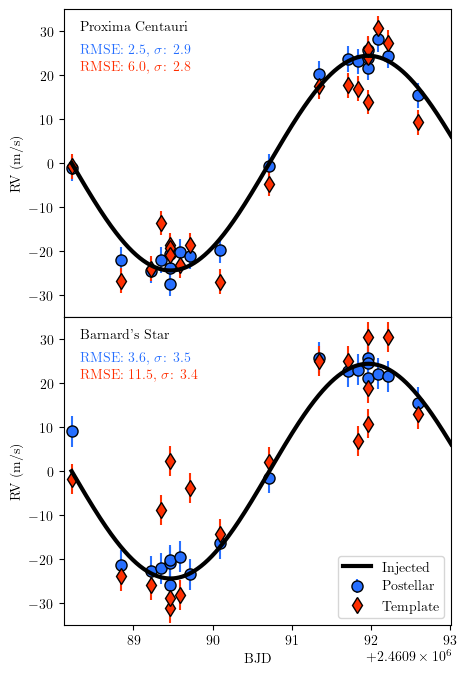

In [141]:
template_color   = "#FF2E00"   # warm tone
postellar_color  = "#256EFF" 
phoenix_color = "#00CC66"
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})
fig, axs = plt.subplots(2,1, figsize=(5,8),sharey=True,sharex=True)
plt.subplots_adjust(wspace=0,hspace=0)

axs[0].errorbar(d,proxmala,np.ones(20)*proxdict['mala'][1],c=postellar_color,alpha=0.99,marker='o',ls="",mec="k",ms=8)
axs[0].errorbar(d, proxtemp,np.ones(20)*proxdict['template'][1],c=template_color,alpha=0.99,marker='d',ls="",mec="k",ms=8)
# axs[0].errorbar(d, phoenixproxmala,np.ones(20)*phoenixpdict['phoenix'][1],c=phoenix_color,alpha=0.99,marker='d',ls="",mec="k",ms=8)



axs[1].errorbar(d, bmala,np.ones(20)*bdict['mala'][1],c=postellar_color,alpha=0.99,marker='o',ls="",mec="k",ms=8,label="Postellar")
axs[1].errorbar(d, btemp,np.ones(20)*bdict['template'][1],c=template_color,alpha=0.99,marker='d',ls="",mec="k",ms=8,label="Template")
# axs[1].errorbar(d, phoenixbmala,np.ones(20)*phoenixbdict['phoenix'][1],c=phoenix_color,alpha=0.99,marker='d',ls="",mec="k",ms=8,label="PHOENIX")

n_dense = 10000 // 4  # number of dense points per cluster
n_sparse = 10000 - 2 * n_dense -2

# Uniform sparse coverage across full orbit
sparse_phases = np.linspace(0, 1, n_sparse, endpoint=False)

# Denser sampling around peaks/troughs
peak_phases = np.linspace(0.20, 0.30, n_dense)
trough_phases = np.linspace(0.70, 0.80, n_dense)
fixed_phases = np.array([0.25,0.75])

# Combine and wrap to [0, 1)
phases = np.sort(np.mod(np.concatenate([sparse_phases, peak_phases, trough_phases, fixed_phases]), 1.0))
K = get_K(5, mp, 0.12)
# Convert to times
dld = 2460988.218692 + phases * 5
phase = 2 * np.pi * ((dld - 2460988.218692) / 5)

R = K * np.cos(phase + (np.pi / 2.0))


max_y = 35
axs[1].text(d[0]+0.1,max_y-5,"Barnard's Star",fontweight='bold')
axs[0].text(d[0]+0.1,max_y-5,"Proxima Centauri",fontweight='bold')

axs[0].text(
    d[0]+0.1, max_y-10,
    rf"RMSE: {pmrmse:.1f}, $\sigma$: {proxdict['mala'][1]:.1f}",
    color=postellar_color
)
axs[0].text(
    d[0]+0.1, max_y-14,
    rf"RMSE: {ptrmse:.1f}, $\sigma$: {proxdict['template'][1]:.1f}",
    color=template_color
)
# axs[0].text(
#     d[0]+0.1, max_y-18,
#     rf"RMSE: {phoenixpmrmse:.1f}, $\sigma$: {phoenixpdict['phoenix'][1]:.1f}",
#     color=phoenix_color
# )

axs[1].text(
    d[0]+0.1, max_y-10,
    rf"RMSE: {bmrmse:.1f}, $\sigma$: {bdict['mala'][1]:.1f}",
    color=postellar_color
)
axs[1].text(
    d[0]+0.1, max_y-14,
    rf"RMSE: {btrmse:.1f}, $\sigma$: {bdict['template'][1]:.1f}",
    color=template_color
)
# axs[1].text(
#     d[0]+0.1, max_y-18,
#     rf"RMSE: {phoenixbmrmse:.1f}, $\sigma$: {phoenixbdict['phoenix'][1]:.1f}",
#     color=phoenix_color
# )

axs[0].plot(dld, R,c="k",zorder=1000,lw=3)
axs[1].plot(dld, R,c="k",zorder=1000,lw=3,label="Injected")
axs[0].set_ylabel("RV (m/s)")
axs[1].set_ylabel("RV (m/s)")
axs[1].set_xlabel("BJD")
axs[1].legend(loc='lower right')
axs[1].set_yticks([-30,-20,-10,0,10,20,30])
plt.ylim(-max_y,max_y)
plt.xlim(dld[0]-0.1,dld[-1]-0.2)
plt.savefig("real_star_rv.pdf",dpi=300)
plt.show()